In [1]:
import torch
import matplotlib.pyplot as plt
import cv2

from VAE import VAE, vae_loss

from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from img_dataloader import dataset_imgs

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
device = "cpu"

In [47]:
def train_vae(vae, dataloader, epochs=100):
    losses = []
    opt = torch.optim.Adam(vae.parameters(), lr=1e-4)

    step = 0

    for epoch in range(epochs):
        epoch_loss = 0
        for images, x_t, noise, t, number in dataloader:
            images = images.to(device)
            recon, mu, logvar = vae(images)

            # Anneal KL weight from 0 -> 1e-4 over first 10k steps
            # to avoid posterior collapse early in training
            kl_w = min(1e-4, step / epochs * 1e-4)
            loss = vae_loss(recon, images, mu, logvar, kl_weight=kl_w)
            epoch_loss += loss.item()

            opt.zero_grad()
            loss.backward()
            opt.step()

            step += 1
        
        losses.append(epoch_loss/len(dataloader))
        print(f"Epoch: {epoch} / {epochs} => loss: {epoch_loss/len(dataloader):.2f}")

In [48]:
dataset = dataset_imgs("Temp Dataset")
dataloader  = DataLoader(dataset, batch_size = 5, shuffle = True)

In [49]:
vae = VAE(ch = 128, latent_channels = 4)

In [50]:
losses = train_vae(vae, dataloader, epochs = 20)

Epoch: 0 / 20 => loss: 0.38
Epoch: 1 / 20 => loss: 0.09
Epoch: 2 / 20 => loss: 0.11
Epoch: 3 / 20 => loss: 0.07
Epoch: 4 / 20 => loss: 0.07
Epoch: 5 / 20 => loss: 0.06
Epoch: 6 / 20 => loss: 0.05
Epoch: 7 / 20 => loss: 0.05
Epoch: 8 / 20 => loss: 0.05
Epoch: 9 / 20 => loss: 0.05
Epoch: 10 / 20 => loss: 0.04
Epoch: 11 / 20 => loss: 0.04
Epoch: 12 / 20 => loss: 0.04
Epoch: 13 / 20 => loss: 0.04
Epoch: 14 / 20 => loss: 0.04
Epoch: 15 / 20 => loss: 0.04
Epoch: 16 / 20 => loss: 0.04
Epoch: 17 / 20 => loss: 0.04
Epoch: 18 / 20 => loss: 0.04
Epoch: 19 / 20 => loss: 0.04


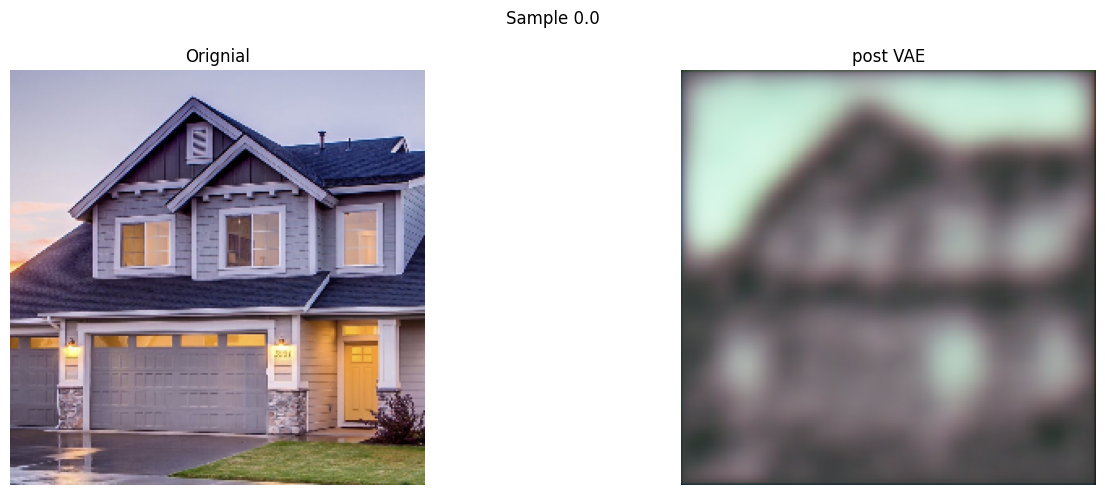

In [55]:
sample = next(iter(dataloader))

img       = sample[0][0].permute(1, 2, 0).cpu().numpy()
noisy_img = sample[1][0].permute(1, 2, 0).cpu().numpy()
noise     = sample[2][0].permute(1, 2, 0).cpu().numpy()

t = sample[3][0].item()
number = sample[4][0].item()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].imshow(img)
ax[0].set_title("Orignial")
ax[0].axis("off")


tensor_img = torch.tensor(img).permute(-1,0,1).unsqueeze(0)
recon_grid, mu, logvar = vae(tensor_img)
plt_recon_img = recon_grid[0].permute(1,2,0).cpu().detach().numpy()

ax[1].imshow(plt_recon_img)
ax[1].set_title("post VAE")
ax[1].axis("off")

plt.suptitle(f"Sample {number}")
plt.tight_layout()
plt.show()

In [ ]:
torch.randn_like(tensor_img)

torch.Size([1, 3, 256, 256])

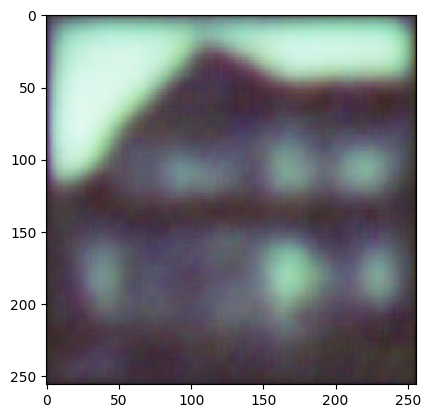